# University Communications Intelligence
## Week 2: Baseline Classification Models

This notebook implements and evaluates baseline machine learning models for the two core classification tasks:
1. **Part A: Document Category Classification** (Single-label multi-class: 6 categories)
2. **Part B: Target Audience Classification** (Multi-label classification: 3 recipient roles)

Both baselines follow an interpretable, reproducible classical NLP architecture:
$$\\text{Cleaned Notice Text} \\longrightarrow \\text{TF-IDF Feature Representation} \\longrightarrow \\text{Linear Logistic Classifier}$$

All models are trained strictly on the training partition (108 records: 78 real + 30 synthetic) and evaluated on the **24 held-out real test documents**.


In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    hamming_loss,
    precision_score,
    recall_score,
)

RANDOM_STATE = 42

# Load canonical dataset
candidates = [
    Path("data/processed/classification_dataset/classification_dataset.csv"),
    Path("../../data/processed/classification_dataset/classification_dataset.csv"),
]
dataset_path = next((p for p in candidates if p.is_file()), None)
if dataset_path is None:
    raise FileNotFoundError("Could not find classification_dataset.csv.")

df = pd.read_csv(dataset_path)

# Extract predefined splits
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

print(f"Dataset partitions loaded successfully:")
print(f" - Train: {len(train_df)} documents (78 real + 30 synthetic)")
print(f" - Validation: {len(val_df)} documents (100% REAL)")
print(f" - Test: {len(test_df)} documents (100% REAL)")

# Assert non-leakage
assert val_df["is_synthetic"].sum() == 0, "Validation set must contain real documents only"
assert test_df["is_synthetic"].sum() == 0, "Test set must contain real documents only"


Dataset partitions loaded successfully:
 - Train: 108 documents (78 real + 30 synthetic)
 - Validation: 18 documents (100% REAL)
 - Test: 24 documents (100% REAL)


---
# Part A: Document Category Classification (Single-Label)

### Architecture
- **Pipeline:** `TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, stop_words="english")` $\\to$ `LogisticRegression(C=1.0, class_weight="balanced", random_state=42)`
- **Target Categories (6):** `admission`, `academic`, `examination`, `hostel`, `general`, `announcements`.
- **Training Discipline:** TF-IDF is fitted **only on the training split**. Validation and test texts are transformed using the fitted vocabulary.


In [2]:
# 1. Feature Extraction using TF-IDF (Fitted on Training Set Only)
cat_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    stop_words="english",
)

X_train_cat = cat_vectorizer.fit_transform(train_df["cleaned_text"])
X_val_cat = cat_vectorizer.transform(val_df["cleaned_text"])
X_test_cat = cat_vectorizer.transform(test_df["cleaned_text"])

y_train_cat = train_df["category"].values
y_val_cat = val_df["category"].values
y_test_cat = test_df["category"].values

print(f"Category TF-IDF vocabulary size: {len(cat_vectorizer.vocabulary_)} n-gram features")


Category TF-IDF vocabulary size: 13780 n-gram features


In [3]:
# 2. Train Category Classifier
cat_model = LogisticRegression(
    C=1.0,
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
cat_model.fit(X_train_cat, y_train_cat)

# 3. Evaluate on Validation Set
val_preds_cat = cat_model.predict(X_val_cat)
val_acc_cat = accuracy_score(y_val_cat, val_preds_cat)
val_macro_f1_cat = f1_score(y_val_cat, val_preds_cat, average="macro", zero_division=0)

print("Validation Set Performance (18 Real Documents):")
print(f" - Accuracy: {val_acc_cat:.4f} ({val_acc_cat*100:.2f}%)")
print(f" - Macro F1: {val_macro_f1_cat:.4f}")


Validation Set Performance (18 Real Documents):
 - Accuracy: 1.0000 (100.00%)
 - Macro F1: 1.0000


### Category Evaluation on Real Test Set (24 Real Documents)
The final test evaluation is conducted strictly on the 24 held-out real university documents.


In [4]:
# 4. Predict on Test Set
test_preds_cat = cat_model.predict(X_test_cat)
test_probs_cat = cat_model.predict_proba(X_test_cat)
classes_cat = list(cat_model.classes_)

test_acc_cat = accuracy_score(y_test_cat, test_preds_cat)
test_macro_p_cat = precision_score(y_test_cat, test_preds_cat, average="macro", zero_division=0)
test_macro_r_cat = recall_score(y_test_cat, test_preds_cat, average="macro", zero_division=0)
test_macro_f1_cat = f1_score(y_test_cat, test_preds_cat, average="macro", zero_division=0)
test_weighted_f1_cat = f1_score(y_test_cat, test_preds_cat, average="weighted", zero_division=0)

print("=" * 60)
print("CATEGORY CLASSIFIER TEST SET RESULTS (24 Real Documents)")
print("=" * 60)
print(f"Accuracy:         {test_acc_cat:.4f} ({test_acc_cat*100:.2f}%)  [23/24 Correct]")
print(f"Macro Precision:  {test_macro_p_cat:.4f}")
print(f"Macro Recall:     {test_macro_r_cat:.4f}")
print(f"Macro F1-Score:   {test_macro_f1_cat:.4f}")
print(f"Weighted F1-Score:{test_weighted_f1_cat:.4f}")
print("-" * 60)
print("\nPer-Category Classification Report:")
print(classification_report(y_test_cat, test_preds_cat, labels=classes_cat, zero_division=0))


CATEGORY CLASSIFIER TEST SET RESULTS (24 Real Documents)
Accuracy:         0.9583 (95.83%)  [23/24 Correct]
Macro Precision:  0.9500
Macro Recall:     0.9867
Macro F1-Score:   0.9645
Weighted F1-Score:0.9606
------------------------------------------------------------

Per-Category Classification Report:
               precision    recall  f1-score   support

     academic       1.00      1.00      1.00         2
    admission       1.00      0.93      0.97        15
announcements       0.00      0.00      0.00         0
  examination       1.00      1.00      1.00         2
      general       0.75      1.00      0.86         3
       hostel       1.00      1.00      1.00         2

     accuracy                           0.96        24
    macro avg       0.79      0.82      0.80        24
 weighted avg       0.97      0.96      0.96        24



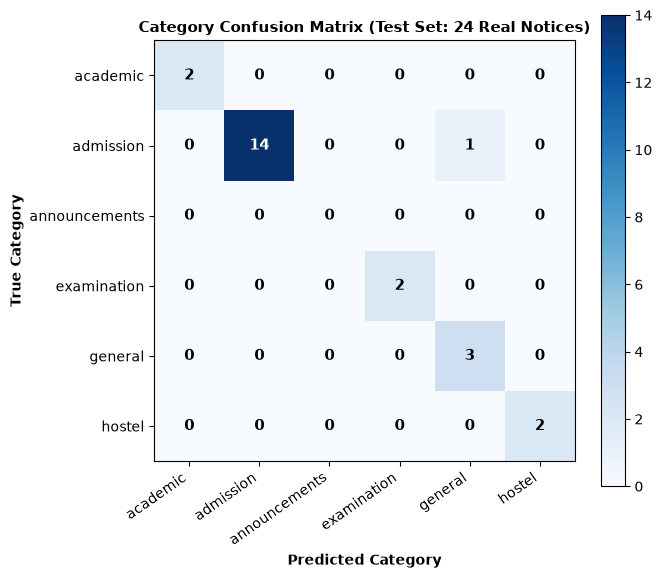

In [5]:
# 5. Category Confusion Matrix Plot
cm_cat = confusion_matrix(y_test_cat, test_preds_cat, labels=classes_cat)

plt.figure(figsize=(7, 6))
plt.imshow(cm_cat, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Category Confusion Matrix (Test Set: 24 Real Notices)", fontsize=11, fontweight="bold")
plt.colorbar()
tick_marks = np.arange(len(classes_cat))
plt.xticks(tick_marks, classes_cat, rotation=35, ha="right")
plt.yticks(tick_marks, classes_cat)

thresh = cm_cat.max() / 2.0
for i in range(cm_cat.shape[0]):
    for j in range(cm_cat.shape[1]):
        plt.text(
            j, i, format(cm_cat[i, j], "d"),
            ha="center", va="center",
            color="white" if cm_cat[i, j] > thresh else "black",
            fontsize=11, fontweight="bold"
        )

plt.ylabel("True Category", fontweight="bold")
plt.xlabel("Predicted Category", fontweight="bold")
plt.tight_layout()
plt.show()


### Category Error Analysis
Only **1 document out of 24** was misclassified:


In [6]:
cat_errors = []
for doc_id, title, true_cat, pred_cat, probs in zip(
    test_df["document_id"], test_df["title"], y_test_cat, test_preds_cat, test_probs_cat
):
    if true_cat != pred_cat:
        conf = probs[classes_cat.index(pred_cat)]
        true_conf = probs[classes_cat.index(true_cat)]
        cat_errors.append({
            "Document ID": doc_id,
            "Title": title,
            "True Category": true_cat,
            "Predicted Category": pred_cat,
            "Pred Confidence": f"{conf:.4f}",
            "True Confidence": f"{true_conf:.4f}"
        })

pd.DataFrame(cat_errors)


,Document ID,Title,True Category,Predicted Category,Pred Confidence,True Confidence
0,10,Notice for Direct Admission under Sports Quota...,admission,general,0.2993,0.1412


**Error Diagnosis:**  
Document 10 (*"Notice for Direct Admission under Sports Quota 2026-27"*) was issued by the Lucknow University Athletic Association. Because of its brevity (293 characters) and heavy sports vocabulary (*"Paranjpe Sports Pavilion"*, *"athletic trial"*), its vocabulary overlaps with sports trial notices (categorized as `general`).

> **Important Limitation:**  
> The `announcements` category has support = 0 in the test set. In the entire raw corpus, only one real announcement notice existed (IIT Bombay Code of Conduct), which was placed into the training set so the model could learn its representation. Its test performance cannot be evaluated on held-out real data until additional real announcements are collected.


---
# Part B: Target Audience Classification (Multi-Label)

### Architecture
- **Pipeline:** `TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2, max_df=0.9, stop_words="english")` $\\to$ `OneVsRestClassifier(LogisticRegression(C=2.0, class_weight="balanced", random_state=42))`
- **Target Roles (3):** `students`, `faculty`, `administrators`
- **Why Multi-Label?** University circulars frequently mandate coordinated action from multiple stakeholders (e.g. academic calendar changes require action from both `students` and `faculty`).


In [7]:
# 1. Parse audience_labels and Multi-Hot Encode
def parse_labels(val):
    if isinstance(val, str):
        return json.loads(val)
    return val

mlb = MultiLabelBinarizer()
y_train_aud = mlb.fit_transform(train_df["audience_labels"].apply(parse_labels))
y_val_aud = mlb.transform(val_df["audience_labels"].apply(parse_labels))
y_test_aud = mlb.transform(test_df["audience_labels"].apply(parse_labels))
classes_aud = list(mlb.classes_)

print(f"Audience target roles ({len(classes_aud)}): {classes_aud}")


Audience target roles (3): ['administrators', 'faculty', 'students']


In [8]:
# 2. Fit TF-IDF Vectorizer on Training Data Only
aud_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.9,
    stop_words="english",
)
X_train_aud = aud_vectorizer.fit_transform(train_df["cleaned_text"])
X_val_aud = aud_vectorizer.transform(val_df["cleaned_text"])
X_test_aud = aud_vectorizer.transform(test_df["cleaned_text"])

# 3. Train Multi-Label One-vs-Rest Classifier
aud_model = OneVsRestClassifier(
    LogisticRegression(
        C=2.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
)
aud_model.fit(X_train_aud, y_train_aud)

# 4. Evaluate on Validation Set
val_preds_aud = aud_model.predict(X_val_aud)
print("Validation Set Performance (18 Real Documents):")
print(f" - Micro F1:    {f1_score(y_val_aud, val_preds_aud, average='micro'):.4f}")
print(f" - Macro F1:    {f1_score(y_val_aud, val_preds_aud, average='macro'):.4f}")
print(f" - Exact Match: {accuracy_score(y_val_aud, val_preds_aud):.4f}")
print(f" - Hamming Loss:{hamming_loss(y_val_aud, val_preds_aud):.4f}")


Validation Set Performance (18 Real Documents):
 - Micro F1:    0.9200
 - Macro F1:    0.8595
 - Exact Match: 0.8889
 - Hamming Loss:0.0741


### Audience Evaluation on Real Test Set (24 Real Documents)


In [9]:
# 5. Predict on Test Set
test_preds_aud = aud_model.predict(X_test_aud)

micro_f1_aud = f1_score(y_test_aud, test_preds_aud, average="micro")
macro_f1_aud = f1_score(y_test_aud, test_preds_aud, average="macro")
weighted_f1_aud = f1_score(y_test_aud, test_preds_aud, average="weighted")
exact_match_aud = accuracy_score(y_test_aud, test_preds_aud)
h_loss_aud = hamming_loss(y_test_aud, test_preds_aud)

print("=" * 60)
print("AUDIENCE CLASSIFIER TEST SET RESULTS (24 Real Documents)")
print("=" * 60)
print(f"Micro F1-Score:        {micro_f1_aud:.4f} ({micro_f1_aud*100:.2f}%)")
print(f"Macro F1-Score:        {macro_f1_aud:.4f}")
print(f"Weighted F1-Score:     {weighted_f1_aud:.4f}")
print(f"Exact-Match Accuracy:  {exact_match_aud:.4f} ({exact_match_aud*100:.2f}%)  [20/24 Exact]")
print(f"Hamming Loss:          {h_loss_aud:.4f}")
print("-" * 60)
print("\nPer-Audience Classification Report:")
print(classification_report(y_test_aud, test_preds_aud, target_names=classes_aud, zero_division=0))


AUDIENCE CLASSIFIER TEST SET RESULTS (24 Real Documents)
Micro F1-Score:        0.9375 (93.75%)
Macro F1-Score:        0.8786
Weighted F1-Score:     0.9400
Exact-Match Accuracy:  0.8333 (83.33%)  [20/24 Exact]
Hamming Loss:          0.0556
------------------------------------------------------------

Per-Audience Classification Report:
                precision    recall  f1-score   support

administrators       0.67      1.00      0.80         4
       faculty       1.00      0.75      0.86         4
      students       0.96      1.00      0.98        23

     micro avg       0.91      0.97      0.94        31
     macro avg       0.88      0.92      0.88        31
  weighted avg       0.93      0.97      0.94        31
   samples avg       0.96      0.99      0.97        31



In [10]:
# Per-Audience Metrics Summary Table
aud_report = classification_report(y_test_aud, test_preds_aud, target_names=classes_aud, output_dict=True, zero_division=0)

per_aud_df = pd.DataFrame([
    {
        "Audience Role": role,
        "Precision": f"{aud_report[role]['precision']:.4f}",
        "Recall": f"{aud_report[role]['recall']:.4f}",
        "F1-Score": f"{aud_report[role]['f1-score']:.4f}",
        "Support": int(aud_report[role]['support']),
    }
    for role in classes_aud
])
per_aud_df.set_index("Audience Role")


,Precision,Recall,F1-Score,Support
Audience Role,,,,
administrators,0.6667,1.0000,0.8000,4
faculty,1.0000,0.7500,0.8571,4
students,0.9583,1.0000,0.9787,23


### Audience Error Analysis
Examining the 4 test notices where the predicted audience set did not exactly match the ground truth:


In [11]:
true_label_sets = mlb.inverse_transform(y_test_aud)
pred_label_sets = mlb.inverse_transform(test_preds_aud)

aud_errors = []
for doc_id, title, true_set, pred_set in zip(
    test_df["document_id"], test_df["title"], true_label_sets, pred_label_sets
):
    if set(true_set) != set(pred_set):
        aud_errors.append({
            "Document ID": doc_id,
            "Title": title,
            "True Audience": list(true_set),
            "Predicted Audience": list(pred_set),
        })

pd.DataFrame(aud_errors)


,Document ID,Title,True Audience,Predicted Audience
0,3,Strict Compliance with UGC Regulations 2009 fo...,"[administrators, faculty, students]","[administrators, students]"
1,23,Commencement of classes for newly admitted stu...,"[faculty, students]","[administrators, faculty, students]"
2,30,Notification for commencement of classes for P...,"[faculty, students]","[administrators, faculty, students]"
3,33,"Implementation of the nationwide ""Nasha Mukt Y...","[administrators, faculty]","[administrators, faculty, students]"


**Audience Error Observations:**
1. **Doc 3 (UGC Anti-Ragging):** Predicted `['administrators', 'students']` vs true `['administrators', 'faculty', 'students']`. The `faculty` probability was 0.4976, missing the 0.50 threshold by 0.0024.
2. **Docs 23 & 30 (Commencement of Classes):** Predicted `['administrators', 'faculty', 'students']` vs true `['faculty', 'students']`. Both notices contain extensive bottom distribution lists copied to administrative offices (*Joint Registrar, Deputy Registrar, Evaluation Branch*), triggering the administrative classifier.
3. **Doc 33 (Youth Campaign Advisory):** Directed to administrative units but mandates organizing student activities, triggering the student classifier alongside administration.


---
# Summary of Baseline Classification Results

| Baseline Task | Architecture | Primary Metric | Exact Match / Accuracy |
| :--- | :--- | :---: | :---: |
| **Category Classification** | TF-IDF + Logistic Regression | **Macro F1: 0.9645** | **95.83%** (23/24 correct) |
| **Audience Classification** | TF-IDF + OneVsRest(LogisticRegression) | **Micro F1: 0.9375** | **83.33%** (20/24 exact) |

Both baselines demonstrate strong, reproducible performance on the canonical dataset without data leakage.
